# 10 · The Fiedler bottleneck and the small vanguard

**Can a structural communication bottleneck trap a paradigm shift inside
a small minority — even when that minority holds decisive evidence?**

Notebooks 06–09 built up the paradigm-competition model: two point
hypotheses M_N (Newtonian) and M_R (Relativistic), an entrenched
population that starts at μ = θ_N with precision λ₀·I, a fixed
relativistic truth θ\* = θ_R, and the per-agent log Bayes factor as the
observable. Notebook 09 found a *paradigm-capture* regime at high
entrenchment — but in 09 **every** community has its own discriminating
evidence: θ_N and θ_R differ on all four dimensions.

This notebook makes the experiment structural. Two coupled changes:

1. **Discovery is localised to one small "vanguard" community.**
   θ_N and θ_R now differ *only* on dimension 4:

   | dim | θ_N | θ_R | Δθ |
   |---|---|---|---|
   | 1 | 0.5 | 0.5 | 0.0 |
   | 2 | 0.5 | 0.5 | 0.0 |
   | 3 | 0.5 | 0.5 | 0.0 |
   | 4 | 0.0 | 2.5 | 2.5 |

   The three large *mainstream* communities (24 agents each) probe basis
   peaks 1–3, where θ_N ≡ θ_R — so their own experiments carry **zero**
   discriminating signal. Only the 8-agent *vanguard* (community 4,
   probing peak 4) can tell M_R from M_N first-hand. Mainstream log
   Bayes factors can move *only* through the trust-weighted social pool.

2. **We induce a low Fiedler value** — the algebraic connectivity λ₂ of
   the graph Laplacian — by thinning the cross-community bridge edges,
   and measure whether the paradigm shift still reaches the mainstream.

This operationalises the spectral-gap reading sketched conceptually in
`archive/v02-norms-as-shared-precision-priors/section_4.tex`, where λ₂
is described as a read-out of "echo-chamber" bottlenecks versus
"well-mixed consensus." Here we turn that into a measured phase
relationship: **mainstream final log BF as a function of the structural
λ₂**, expecting a threshold below which the shift stays trapped in the
vanguard.

All multivariate-Gaussian inference machinery is copied verbatim from
notebook 09 (which copied it from 08). No `src/` changes.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from src.network import build_adjacency

sns.set_theme(context='notebook', style='whitegrid')
print('imports ok')

imports ok


## §1 · Population layout and Fiedler calibration

The population is **asymmetric**: three mainstream communities of 24
agents and one vanguard of 8 (N = 80). We hold the within-community edge
probability fixed (`intra_prob = 0.4` — every community internally
well-connected) and sweep only the between-community bridge probability
`inter_prob ∈ {0.05, 0.02, 0.01, 0.005, 0.002, 0.0}`, with 6 seeds each.

The control variable is the **normalised-Laplacian Fiedler value**
λ₂ = second-smallest eigenvalue of L_sym = I − D^(−1/2) A D^(−1/2)
(bounded in [0, 2]). The normalised Laplacian is the right choice here:
the unnormalised λ₂ would fold the 8-vs-24 block-degree asymmetry into
the control variable. Multi-seed averaging converts the discrete
`inter_prob` knob into a continuous λ₂ axis with error bars.

We **filter** out seeds where the vanguard subgraph is internally
disconnected — rare at `intra_prob = 0.4`, but confounding when it
happens (the vanguard could not even reach internal consensus). Note
that the whole-graph disconnection at `inter_prob = 0.0` is *not*
filtered — that is the experiment's desired endpoint.

N = 80: 3 mainstream communities x 24 + 1 vanguard x 8  (vanguard = community index 3)


vanguard-connectivity filter: discarded 17 of 72 seeds


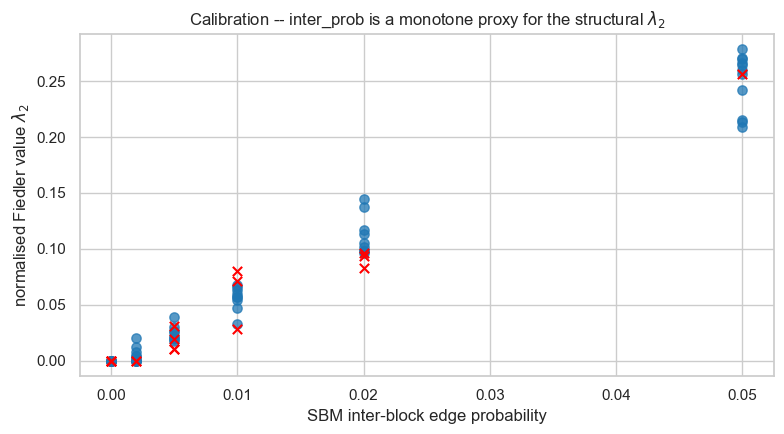


inter_prob   mean norm lambda2   mean unnorm lambda2   seeds kept
  0.05           0.2496               2.127             11/12
  0.02           0.1124               0.836             9/12
  0.01           0.0560               0.435             9/12
  0.005          0.0252               0.200             8/12
  0.002          0.0051               0.035             10/12
  0             -0.0000              -0.000             8/12


In [2]:
K = 4
N_MAINSTREAM = 3
MAINSTREAM_SIZE = 24
VANGUARD_SIZE = 8
N = N_MAINSTREAM * MAINSTREAM_SIZE + VANGUARD_SIZE          # 80
VANGUARD_COMM = N_MAINSTREAM                                # community index 3


def make_membership(vanguard_size=VANGUARD_SIZE, n_mainstream=N_MAINSTREAM,
                    mainstream_size=MAINSTREAM_SIZE):
    """Asymmetric block-membership array: mainstream communities first
    (indices 0..n_mainstream-1), the vanguard last."""
    blocks = [np.full(mainstream_size, c, dtype=np.int32)
              for c in range(n_mainstream)]
    blocks.append(np.full(vanguard_size, n_mainstream, dtype=np.int32))
    return np.concatenate(blocks)


membership = make_membership()
vanguard_idx = np.where(membership == VANGUARD_COMM)[0]
mainstream_idx = np.where(membership != VANGUARD_COMM)[0]
print(f'N = {N}: {N_MAINSTREAM} mainstream communities x {MAINSTREAM_SIZE} '
      f'+ 1 vanguard x {VANGUARD_SIZE}  (vanguard = community index {VANGUARD_COMM})')


# --- Fiedler value: lambda_2 of the normalised graph Laplacian ---
def fiedler_value(A):
    """Second-smallest eigenvalue of L_sym = I - D^{-1/2} A D^{-1/2}.
    Bounded in [0, 2]; robust to the 8-vs-24 block-degree asymmetry.
    Equals 0 exactly when the graph is disconnected."""
    A = np.asarray(A, dtype=np.float64)
    deg = A.sum(axis=1)
    with np.errstate(divide='ignore'):
        d_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
    L_sym = np.eye(A.shape[0]) - (d_inv_sqrt[:, None] * A * d_inv_sqrt[None, :])
    return float(np.linalg.eigvalsh(L_sym)[1])


def fiedler_value_unnormalised(A):
    """lambda_2 of L = D - A. Calibration footnote only -- it folds the
    block-degree asymmetry into the value, which is why the control axis
    uses the normalised version."""
    A = np.asarray(A, dtype=np.float64)
    L = np.diag(A.sum(axis=1)) - A
    return float(np.linalg.eigvalsh(L)[1])


# --- The Fiedler control: sweep inter_prob, hold intra_prob fixed ---
INTRA_PROB = 0.4
INTER_PROB_GRID = (0.05, 0.02, 0.01, 0.005, 0.002, 0.0)
# An 8-node vanguard block at intra_prob=0.4 disconnects internally ~40% of
# the time, so the connectivity filter discards far more than the plan's
# "~1 per level" estimate. 12 draws restores the plan's intended ~6 usable
# seeds per inter_prob level.
N_SEEDS = 12


def build_sweep_adjacency(inter_prob, seed):
    return build_adjacency(
        n_agents=N, mean_degree=6, rewiring_p=0.1, seed=seed,
        kind='planted_sbm', society_membership=membership,
        intra_prob=INTRA_PROB, inter_prob=inter_prob,
    )


def vanguard_connected(A):
    """True iff the vanguard's *internal* subgraph is connected. This is
    independent of inter_prob -- whole-graph disconnection at
    inter_prob=0 is the desired endpoint, not a filter condition."""
    G = nx.from_numpy_array(np.asarray(A))
    return nx.is_connected(G.subgraph(vanguard_idx.tolist()))


# Calibrate: for each (inter_prob, seed) build the SBM, filter, record lambda_2.
calib = []          # rows: (inter_prob, seed, lambda2_norm, lambda2_unnorm, ok)
for ip in INTER_PROB_GRID:
    for sd in range(N_SEEDS):
        A = build_sweep_adjacency(ip, sd)
        ok = vanguard_connected(A)
        calib.append((ip, sd, fiedler_value(A), fiedler_value_unnormalised(A),
                      float(ok)))
calib = np.array(calib)
n_discarded = int((calib[:, 4] == 0.0).sum())
print(f'vanguard-connectivity filter: discarded {n_discarded} of '
      f'{len(INTER_PROB_GRID) * N_SEEDS} seeds')

fig, ax = plt.subplots(figsize=(8, 4.5))
for ip in INTER_PROB_GRID:
    rows = calib[calib[:, 0] == ip]
    kept = rows[rows[:, 4] > 0]
    ax.scatter(np.full(len(kept), ip), kept[:, 2], color='#1f77b4',
               s=45, alpha=0.75)
    disc = rows[rows[:, 4] == 0]
    ax.scatter(np.full(len(disc), ip), disc[:, 2], color='red',
               marker='x', s=45)
ax.set(xlabel='SBM inter-block edge probability',
       ylabel='normalised Fiedler value $\\lambda_2$',
       title='Calibration -- inter_prob is a monotone proxy for the structural $\\lambda_2$')
plt.tight_layout()
plt.show()

print()
print('inter_prob   mean norm lambda2   mean unnorm lambda2   seeds kept')
for ip in INTER_PROB_GRID:
    rows = calib[calib[:, 0] == ip]
    kept = rows[rows[:, 4] > 0]
    use = kept if len(kept) else rows
    print(f'  {ip:<8g}     {use[:, 2].mean():8.4f}            '
          f'{use[:, 3].mean():8.3f}             {len(kept)}/{N_SEEDS}')

## §2 · Inference helpers — copied verbatim from notebook 09

The two hypotheses (with the new Δθ = (0,0,0,2.5)), the Gaussian-bump
basis, the multivariate-Gaussian inference (`private_update_vec`,
`precision_pool_vec`, `surprisal_matrix_vec`), the point-Bayes-factor
helper, and the active-inference policy are **lifted verbatim from
notebook 09 §2–§5**. Duplication is cheaper than premature abstraction;
`src/` promotion is deferred to a separate plan.

`agent_x_grids` is built here as a module global — community membership
(24 + 24 + 24 + 8) is fixed across the entire sweep; only the network
edges change.

In [3]:
# === Hypotheses -- pure localised discrimination (Delta theta on dim 4 only) ===
theta_N = jnp.array([0.5, 0.5, 0.5, 0.0])
theta_R = jnp.array([0.5, 0.5, 0.5, 2.5])
delta_theta = theta_R - theta_N                      # (0, 0, 0, 2.5)

LOGBF_THRESHOLD = 10.0       # Kass & Raftery (1995) "decisive" evidence
sigma_default = 0.5

# === Basis + world -- copied verbatim from notebook 09 (itself from nb08) ===
x_peaks = jnp.array([1.0, 3.0, 5.0, 7.0])
basis_w = 0.6
sigma = sigma_default


def school_x_grid(k, n_pts=3, spread=0.4):
    centre = float(x_peaks[k])
    return tuple(np.linspace(centre - spread, centre + spread, n_pts).tolist())


SCHOOL_GRIDS = [school_x_grid(k) for k in range(K)]

# community membership is fixed across the whole sweep -> agent_x_grids is a
# module global (only the network edges change per sweep entry).
agent_x_grids = jnp.asarray(
    np.stack([SCHOOL_GRIDS[s] for s in membership]),
    dtype=jnp.float32,
)


def h_basis(x):
    x_ = jnp.asarray(x)[..., None]
    return jnp.exp(-((x_ - x_peaks) ** 2) / (basis_w ** 2))


def h0(x):
    return jnp.zeros_like(jnp.asarray(x))


def sample_o(x, theta_star, key):
    mean = h0(x) + h_basis(x) @ theta_star
    noise = jax.random.normal(key, jnp.shape(x)) * sigma
    return mean + noise


# === Multivariate-Gaussian inference -- copied verbatim from notebook 09 ===
EPS = 1e-9


def private_update_vec(mu, Lambda, x, o):
    h = h_basis(x)                               # (N, K)
    sigma2 = sigma ** 2
    HHT = h[:, :, None] * h[:, None, :] / sigma2
    Lambda_new = Lambda + HHT
    Lmu = jnp.einsum('nij,nj->ni', Lambda, mu)
    info = h * ((o - h0(x))[:, None]) / sigma2
    rhs = Lmu + info
    mu_new = jax.vmap(jnp.linalg.solve)(
        Lambda_new + EPS * jnp.eye(K)[None], rhs
    )
    return mu_new, Lambda_new


def precision_pool_vec(mu_priv, Lambda_priv, gamma, mask):
    weights = gamma * mask
    row_sum = weights.sum(axis=1, keepdims=True) + EPS
    w = weights / row_sum
    Lambda_pool = jnp.einsum('ij,jkl->ikl', w, Lambda_priv)
    Lmu_priv = jnp.einsum('jkl,jl->jk', Lambda_priv, mu_priv)
    num = jnp.einsum('ij,jk->ik', w, Lmu_priv)
    mu_pool = jax.vmap(jnp.linalg.solve)(
        Lambda_pool + EPS * jnp.eye(K)[None], num
    )
    return mu_pool, Lambda_pool


def surprisal_matrix_vec(mu_priv, Lambda_priv, x_obs, o_obs, mask):
    h_i = h_basis(x_obs)
    def per_j_quadratic(Lambda_j):
        return jax.vmap(lambda h: jnp.linalg.solve(Lambda_j + EPS * jnp.eye(K), h))(h_i)
    Sigma_h = jax.vmap(per_j_quadratic)(Lambda_priv)
    quad = jnp.einsum('ik,jik->ij', h_i, Sigma_h)
    pred_mean = h0(x_obs)[:, None] + h_i @ mu_priv.T
    pred_var = sigma ** 2 + quad
    log_norm = -0.5 * jnp.log(2.0 * jnp.pi * pred_var)
    log_kern = -0.5 * (o_obs[:, None] - pred_mean) ** 2 / pred_var
    return (-(log_norm + log_kern)) * mask


# === Point-Bayes-factor -- copied verbatim from notebook 09 ===
def log_bayes_factor(mu, Lambda, theta_N=theta_N, theta_R=theta_R):
    """Per-agent log BF (R over N). mu (N,K), Lambda (N,K,K) -> (N,)."""
    d_N = mu - theta_N
    d_R = mu - theta_R
    q_N = jnp.einsum('ni,nij,nj->n', d_N, Lambda, d_N)
    q_R = jnp.einsum('ni,nij,nj->n', d_R, Lambda, d_R)
    return 0.5 * (q_N - q_R)


def community_log_bf(mu, Lambda, membership):
    """Mean log BF per community. Returns shape (K_communities,)."""
    lbf = log_bayes_factor(mu, Lambda)
    return jnp.stack([
        lbf[jnp.asarray(membership) == s].mean()
        for s in range(int(membership.max()) + 1)
    ])


# === Active-inference policy + trust constants -- verbatim from notebook 09 ===
TRUST_RHO = 1.0
TRUST_N0 = 1.0
TRUST_EPS0 = 1.0
COST_SLOPE = 0.5
BETA_EXP = 1.0


def expected_info_gain_vec(Lambda, x_grid):
    sign_old, logdet_old = jnp.linalg.slogdet(Lambda + EPS * jnp.eye(K)[None])
    h_grid = h_basis(x_grid)
    HHT = h_grid[..., :, None] * h_grid[..., None, :] / (sigma ** 2)
    Lambda_post = Lambda[:, None] + HHT
    sign_new, logdet_new = jnp.linalg.slogdet(
        Lambda_post + EPS * jnp.eye(K)[None, None]
    )
    return 0.5 * (logdet_new - logdet_old[:, None])


def choose_x(Lambda, x_grid, key):
    eig = expected_info_gain_vec(Lambda, x_grid)
    cost = COST_SLOPE * jnp.abs(x_grid)
    logits = BETA_EXP * (eig - cost)
    keys = jax.random.split(key, x_grid.shape[0])
    idx = jax.vmap(jax.random.categorical)(keys, logits)
    return jnp.take_along_axis(x_grid, idx[:, None], axis=1)[:, 0]


def time_to_conversion(log_bf_series, threshold=LOGBF_THRESHOLD):
    """First-crossing time for the threshold. None if never crossed."""
    over = np.where(np.asarray(log_bf_series) >= threshold)[0]
    return int(over[0]) if over.size else None


print('inference + policy helpers loaded (copied from nb09; src/ promotion deferred)')
print(f'Delta theta = {np.asarray(delta_theta)}  -- discrimination lives only on dim 4')

inference + policy helpers loaded (copied from nb09; src/ promotion deferred)
Delta theta = [0.  0.  0.  2.5]  -- discrimination lives only on dim 4


## §3 · Parameterised rollout — the network as a traced argument

Notebook 09's `step_vec` closed over the global `A_self`. This notebook
sweeps the network, so `A_self` changes per (inter_prob, seed). The fix:
make `step_vec(state, theta_star, A_self)` take the adjacency as a
**traced JAX argument**. It is jitted once and the single compilation is
reused across every sweep entry, because N and all array shapes are
constant. `init_population_entrenched` and `rollout` likewise take
`A_self` as an explicit argument.

In [4]:
@jax.jit
def step_vec(state, theta_star, A_self):
    """One world-step. Both theta* and the network A_self are traced
    arguments -- A_self changes per (inter_prob, seed) across the sweep,
    so it cannot be a closed-over global. JAX reuses the single
    compilation across all sweep entries because N and every array shape
    are constant."""
    key_pol, key_obs, key_next = jax.random.split(state['key'], 3)
    x_chosen = choose_x(state['Lambda'], agent_x_grids, key_pol)
    o_obs = sample_o(x_chosen, theta_star, key_obs)
    mu_priv, Lambda_priv = private_update_vec(
        state['mu'], state['Lambda'], x_chosen, o_obs
    )
    mu_pool, Lambda_pool = precision_pool_vec(
        mu_priv, Lambda_priv, state['gamma'], A_self
    )
    epsilon = surprisal_matrix_vec(mu_priv, Lambda_priv, x_chosen, o_obs, A_self)
    alpha_new = TRUST_RHO * state['alpha'] + A_self
    beta_new = TRUST_RHO * state['beta'] + epsilon
    gamma_raw = (alpha_new / (beta_new + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma_new = (gamma_raw / rs) * A_self
    new_state = dict(
        mu=mu_pool, Lambda=Lambda_pool,
        alpha=alpha_new, beta=beta_new, gamma=gamma_new,
        key=key_next,
    )
    return new_state, dict(x=x_chosen, o=o_obs)


def init_population_entrenched(theta_N, lambda_0, A_self, seed=0):
    """All agents start at mu = theta_N, Lambda = lambda_0 * I. Trust at
    the uniform Gamma prior over the closed neighbourhood A_self."""
    mu = jnp.broadcast_to(theta_N, (N, K)).astype(jnp.float32)
    Lambda = (lambda_0 * jnp.eye(K))[None].repeat(N, axis=0).astype(jnp.float32)
    alpha = TRUST_N0 * A_self
    beta = TRUST_N0 * TRUST_EPS0 * A_self
    gamma_raw = (alpha / (beta + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma = (gamma_raw / rs) * A_self
    return dict(mu=mu, Lambda=Lambda, alpha=alpha, beta=beta, gamma=gamma,
                key=jax.random.PRNGKey(seed))


def rollout(state, A_self, T=300, snap_every=4, theta_star=theta_R):
    snapshots = []
    log_bf_per_t = []
    log_bf_per_community = []
    for t in range(T):
        state, _ = step_vec(state, theta_star, A_self)
        lbf = log_bayes_factor(state['mu'], state['Lambda'])
        log_bf_per_t.append(float(lbf.mean()))
        log_bf_per_community.append(np.asarray(community_log_bf(
            state['mu'], state['Lambda'], membership)))
        if t % snap_every == 0:
            snapshots.append({
                'step': t,
                'mu': np.asarray(state['mu']),
                'Lambda': np.asarray(state['Lambda']),
                'alpha': np.asarray(state['alpha']),
                'beta': np.asarray(state['beta']),
                'gamma': np.asarray(state['gamma']),
            })
    return (state, snapshots, np.asarray(log_bf_per_t),
            np.stack(log_bf_per_community))


# --- smoke test: one short rollout to confirm the parameterised core runs ---
A_smoke = jnp.asarray(build_sweep_adjacency(0.05, 0)) + jnp.eye(N)
_s = init_population_entrenched(theta_N, lambda_0=30.0, A_self=A_smoke, seed=0)
_s, _snaps, _lbf_m, _lbf_c = rollout(_s, A_smoke, T=40, snap_every=10)
print(f'smoke rollout ok -- T=40, {len(_snaps)} snapshots, '
      f'final mean log BF = {_lbf_m[-1]:+.2f}')
print('  per-community final log BF: '
      + np.array2string(_lbf_c[-1], precision=1, floatmode='fixed')
      + f'  (community {VANGUARD_COMM} = vanguard)')

smoke rollout ok -- T=40, 4 snapshots, final mean log BF = -75.59
  per-community final log BF: [-76.5 -77.3 -77.3 -62.8]  (community 3 = vanguard)


## §4 · Headline — the Fiedler sweep

Run all (inter_prob, seed) rollouts at T = 300, λ₀ = 30. The headline
plots the **mainstream final mean log BF** (communities 1–3) against the
**structural Fiedler value λ₂**, with error bars over seeds. The
vanguard's own final log BF is overlaid as a reference band — it should
be high and roughly λ₂-independent, because the vanguard's own evidence
does not depend on bridge density.

The expected shape: a threshold in λ₂ below which the mainstream stays
near its entrenched start (≈ −½·λ₀·Δθ₄² = −93.75) and above which it
crosses the +10 decisive-evidence line. That threshold is the
"vanguard-trapped" regime — a paradigm shift held captive by graph
structure, not by missing evidence.

sweep done -- 55 (inter_prob, seed) runs (T=300, lambda_0=30)


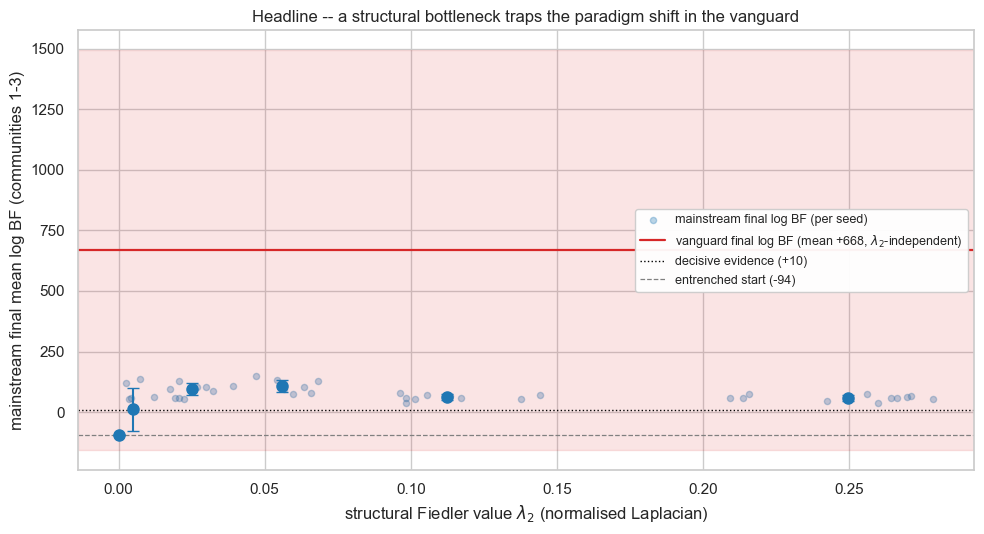


inter_prob   mean lambda2   mainstream final log BF      vanguard final log BF
  0.05         0.2496        +57.70 +/-  10.88           +71.40
  0.02         0.1124        +61.15 +/-  12.10          +101.41
  0.01         0.0560       +106.49 +/-  24.59          +220.11
  0.005        0.0252        +94.40 +/-  24.11          +388.31
  0.002        0.0051        +11.31 +/-  89.55         +1252.09
  0           -0.0000        -93.75 +/-   0.00         +2179.13


In [5]:
LAMBDA0 = 30.0
T_SWEEP = 300

# rows: (inter_prob, seed, lambda2, mainstream_final_lbf, vanguard_final_lbf)
sweep_rows = []
for ip in INTER_PROB_GRID:
    for sd in range(N_SEEDS):
        A_np = build_sweep_adjacency(ip, sd)
        if not vanguard_connected(A_np):
            continue
        A_self = jnp.asarray(A_np) + jnp.eye(N)
        lam2 = fiedler_value(A_np)
        st = init_population_entrenched(theta_N, lambda_0=LAMBDA0,
                                        A_self=A_self, seed=sd)
        _, _, _, lbf_comm = rollout(st, A_self, T=T_SWEEP,
                                    snap_every=T_SWEEP + 1)
        mains = float(lbf_comm[-1, :VANGUARD_COMM].mean())
        van = float(lbf_comm[-1, VANGUARD_COMM])
        sweep_rows.append((ip, sd, lam2, mains, van))
sweep = np.array(sweep_rows)
print(f'sweep done -- {len(sweep)} (inter_prob, seed) runs '
      f'(T={T_SWEEP}, lambda_0={LAMBDA0:g})')

init_lbf = -0.5 * LAMBDA0 * float(jnp.sum(delta_theta ** 2))

fig, ax = plt.subplots(figsize=(10, 5.5))

# raw per-seed points (light)
ax.scatter(sweep[:, 2], sweep[:, 3], color='#1f77b4', s=20, alpha=0.30,
           label='mainstream final log BF (per seed)')

# per-inter_prob aggregate with error bars over seeds
for ip in INTER_PROB_GRID:
    rows = sweep[sweep[:, 0] == ip]
    if len(rows) == 0:
        continue
    ax.errorbar(rows[:, 2].mean(), rows[:, 3].mean(), yerr=rows[:, 3].std(),
                fmt='o', color='#1f77b4', ms=8, capsize=4,
                ecolor='#1f77b4', elinewidth=1.5, zorder=3)

# vanguard reference band (control: should be high, lambda_2-independent)
van_mean, van_std = sweep[:, 4].mean(), sweep[:, 4].std()
ax.axhspan(van_mean - van_std, van_mean + van_std, color='#d62728', alpha=0.12)
ax.axhline(van_mean, color='#d62728', lw=1.6,
           label=f'vanguard final log BF (mean {van_mean:+.0f}, $\\lambda_2$-independent)')

ax.axhline(LOGBF_THRESHOLD, color='black', ls=':', lw=1.0,
           label=f'decisive evidence (+{LOGBF_THRESHOLD:.0f})')
ax.axhline(init_lbf, color='grey', ls='--', lw=0.9,
           label=f'entrenched start ({init_lbf:+.0f})')

ax.set(xlabel='structural Fiedler value $\\lambda_2$ (normalised Laplacian)',
       ylabel='mainstream final mean log BF (communities 1-3)',
       title='Headline -- a structural bottleneck traps the paradigm shift in the vanguard')
ax.legend(loc='center right', fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

print()
print('inter_prob   mean lambda2   mainstream final log BF      vanguard final log BF')
for ip in INTER_PROB_GRID:
    rows = sweep[sweep[:, 0] == ip]
    if len(rows) == 0:
        print(f'  {ip:<8g}   (all seeds discarded)')
        continue
    print(f'  {ip:<8g}   {rows[:, 2].mean():8.4f}     '
          f'{rows[:, 3].mean():+9.2f} +/- {rows[:, 3].std():6.2f}        '
          f'{rows[:, 4].mean():+9.2f}')

## §5 · Time-series contrast — well-connected vs bottlenecked

Two single runs: one well-connected (`inter_prob = 0.05`) and one
bottlenecked (`inter_prob = 0.002`), each at the first seed with an
internally-connected vanguard. Per-community log BF over time, vanguard
drawn thick. The qualitative story: in the well-connected run the
mainstream rises with a lag *after* the vanguard saturates; in the
bottlenecked run the vanguard saturates alone while the mainstream stays
pinned in the entrenched basin.

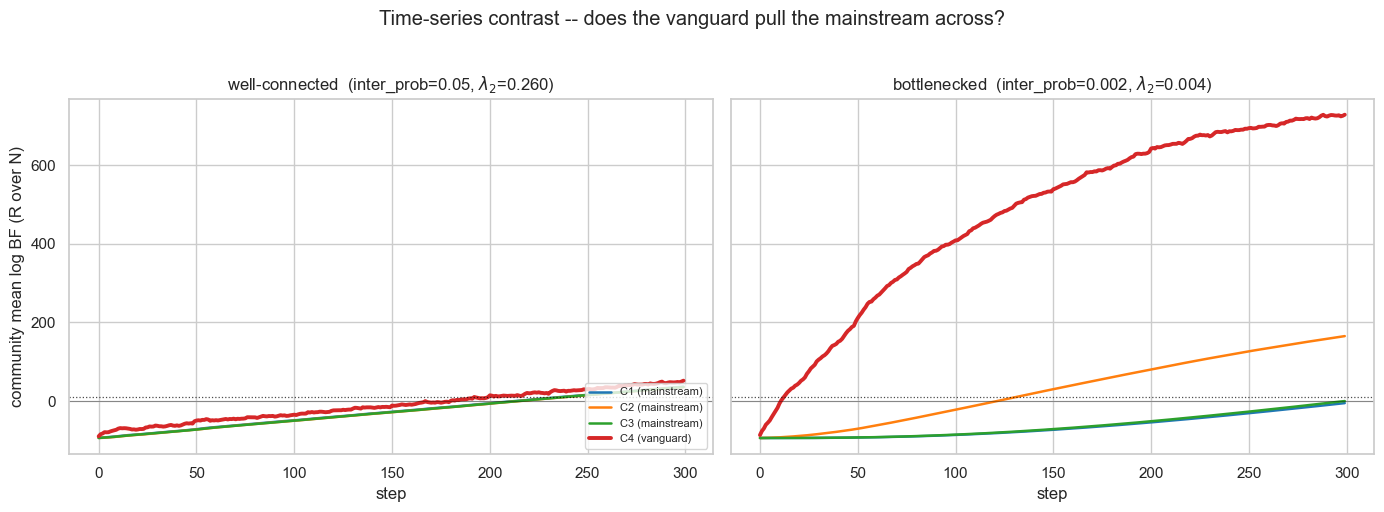

  well-connected: vanguard converts at t=192, mainstream-mean converts at t=237, mainstream final log BF = +36.0
    bottlenecked: vanguard converts at t=13, mainstream-mean converts at t=230, mainstream final log BF = +53.5


In [6]:
def run_named(inter_prob, seed, T=300, snap_every=4):
    A_np = build_sweep_adjacency(inter_prob, seed)
    A_self = jnp.asarray(A_np) + jnp.eye(N)
    st = init_population_entrenched(theta_N, lambda_0=LAMBDA0,
                                    A_self=A_self, seed=seed)
    state, snaps, lbf_m, lbf_c = rollout(st, A_self, T=T, snap_every=snap_every)
    return dict(A_np=A_np, A_self=A_self, snaps=snaps, lbf_m=lbf_m, lbf_c=lbf_c,
                lam2=fiedler_value(A_np), inter_prob=inter_prob, seed=seed)


def first_connected_seed(inter_prob):
    for sd in range(N_SEEDS):
        if vanguard_connected(build_sweep_adjacency(inter_prob, sd)):
            return sd
    return 0


run_hi = run_named(0.05, first_connected_seed(0.05))
run_lo = run_named(0.002, first_connected_seed(0.002))

palette = sns.color_palette('tab10', K)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
T_axis = np.arange(len(run_hi['lbf_c']))
for ax, run, tag in [
    (axes[0], run_hi, 'well-connected'),
    (axes[1], run_lo, 'bottlenecked'),
]:
    for s in range(K):
        is_van = (s == VANGUARD_COMM)
        ax.plot(T_axis, run['lbf_c'][:, s], color=palette[s],
                lw=2.8 if is_van else 1.8,
                label=f'C{s + 1}' + (' (vanguard)' if is_van else ' (mainstream)'))
    ax.axhline(0.0, color='black', lw=0.6, alpha=0.4)
    ax.axhline(LOGBF_THRESHOLD, color='black', ls=':', lw=0.9, alpha=0.7)
    ax.set(xlabel='step',
           title=f'{tag}  (inter_prob={run["inter_prob"]:g}, '
                 f'$\\lambda_2$={run["lam2"]:.3f})')
axes[0].set_ylabel('community mean log BF (R over N)')
axes[0].legend(loc='lower right', fontsize=8)
plt.suptitle('Time-series contrast -- does the vanguard pull the mainstream across?',
             y=1.02)
plt.tight_layout()
plt.show()

for run, name in [(run_hi, 'well-connected'), (run_lo, 'bottlenecked')]:
    van_t = time_to_conversion(run['lbf_c'][:, VANGUARD_COMM])
    mains_series = run['lbf_c'][:, :VANGUARD_COMM].mean(axis=1)
    mains_t = time_to_conversion(mains_series)
    print(f'{name:>16s}: vanguard converts at t={van_t}, '
          f'mainstream-mean converts at t={mains_t}, '
          f'mainstream final log BF = {mains_series[-1]:+.1f}')

## §6 · Trust compensates structure — the effective influence Fiedler value

The structural λ₂ is fixed by the 0/1 adjacency. But the *influence*
graph is the trust-weighted graph γ ⊙ A, and γ evolves. For the same two
runs we compute the time-varying λ₂ of the normalised Laplacian of
γ ⊙ A at each snapshot (symmetrised — the influence channel is
bidirectional even though trust weights are not) and compare it to the
fixed structural λ₂.

If growing vanguard trust opens the effective spectral gap even when the
structural one is pinned low, the effective λ₂(t) rises above the
structural dashed line. This is the paper-facing diagnostic for the
spectral-gap framing in
`archive/v02-norms-as-shared-precision-priors/section_4.tex`.

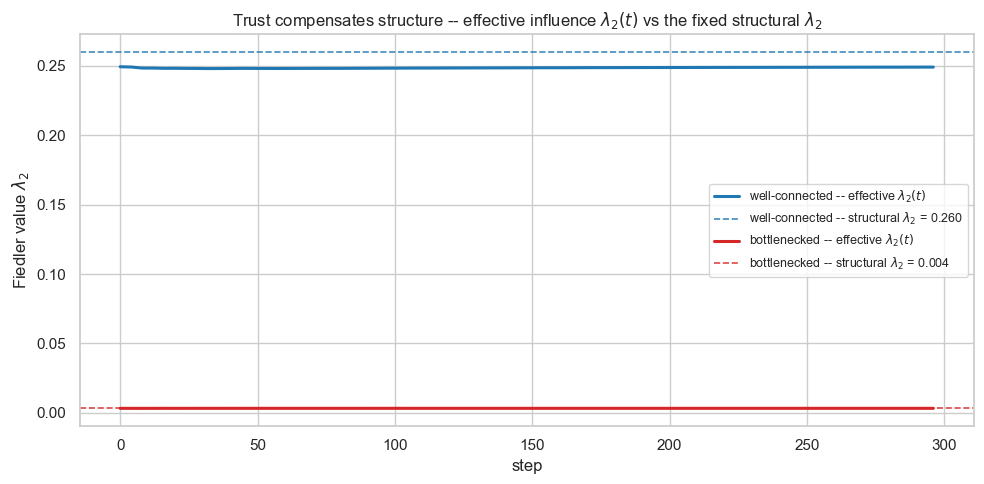

  well-connected: structural lambda2 = 0.2598,  effective lambda2  t=0 -> 0.2493,  t=end -> 0.2490
    bottlenecked: structural lambda2 = 0.0037,  effective lambda2  t=0 -> 0.0032,  t=end -> 0.0032


In [7]:
def influence_fiedler(gamma, A_self):
    """lambda_2 of the normalised Laplacian of the trust-weighted influence
    graph gamma (x) A. gamma is row-normalised and asymmetric, so we
    symmetrise to (W + W^T)/2 before taking the (undirected) spectral gap
    -- the influence channel is bidirectional even though trust weights
    are not. Self-loops are dropped: the spectral gap is about
    between-node coupling."""
    W = np.asarray(gamma) * np.asarray(A_self)
    np.fill_diagonal(W, 0.0)
    W = 0.5 * (W + W.T)
    deg = W.sum(axis=1)
    with np.errstate(divide='ignore'):
        d_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
    L_sym = np.eye(W.shape[0]) - (d_inv_sqrt[:, None] * W * d_inv_sqrt[None, :])
    return float(np.linalg.eigvalsh(L_sym)[1])


fig, ax = plt.subplots(figsize=(10, 5))
for run, name, color in [(run_hi, 'well-connected', '#1f77b4'),
                         (run_lo, 'bottlenecked', '#d62728')]:
    steps = np.array([s['step'] for s in run['snaps']])
    infl = np.array([influence_fiedler(s['gamma'], run['A_self'])
                     for s in run['snaps']])
    ax.plot(steps, infl, color=color, lw=2.2,
            label=f'{name} -- effective $\\lambda_2(t)$')
    ax.axhline(run['lam2'], color=color, ls='--', lw=1.2, alpha=0.85,
               label=f'{name} -- structural $\\lambda_2$ = {run["lam2"]:.3f}')
ax.set(xlabel='step', ylabel='Fiedler value $\\lambda_2$',
       title='Trust compensates structure -- effective influence $\\lambda_2(t)$ vs the fixed structural $\\lambda_2$')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

for run, name in [(run_hi, 'well-connected'), (run_lo, 'bottlenecked')]:
    infl0 = influence_fiedler(run['snaps'][0]['gamma'], run['A_self'])
    inflT = influence_fiedler(run['snaps'][-1]['gamma'], run['A_self'])
    print(f'{name:>16s}: structural lambda2 = {run["lam2"]:.4f},  '
          f'effective lambda2  t=0 -> {infl0:.4f},  t=end -> {inflT:.4f}')

## §7 · Trust asymmetry — who listens to whom

The mechanism behind §4–§6. Block-mean trust α/β between the mainstream
and the vanguard, split by direction:

- **mainstream → vanguard** (trust the mainstream places in the
  vanguard): the vanguard predicts the mainstream's non-discriminating
  dim-1–3 observations fine, so this stays high — the mainstream keeps
  listening.
- **vanguard → mainstream** (trust the vanguard places in the
  mainstream): the mainstream cannot predict the vanguard's dim-4
  observations (their μ₄ is stuck at the entrenched prior), so this
  decays — the vanguard tunes the mainstream out.

The asymmetry *favours* propagation: the binding constraint is
structural (how many bridge edges exist), not a trust breakdown.

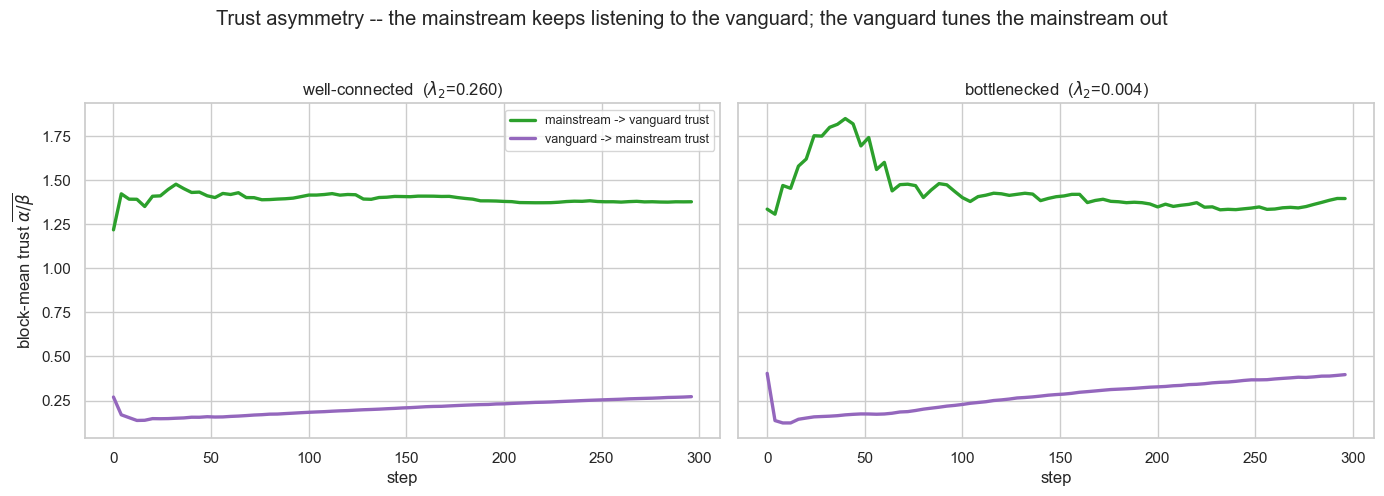

  well-connected: mainstream->vanguard 1.218 -> 1.377   vanguard->mainstream 0.270 -> 0.272
    bottlenecked: mainstream->vanguard 1.336 -> 1.396   vanguard->mainstream 0.404 -> 0.397


In [8]:
src_main = np.isin(membership, np.arange(VANGUARD_COMM))
tgt_van = (membership == VANGUARD_COMM)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, run, name in [(axes[0], run_hi, 'well-connected'),
                      (axes[1], run_lo, 'bottlenecked')]:
    steps = np.array([s['step'] for s in run['snaps']])
    mask_np = np.asarray(run['A_self']) > 0
    alpha_t = np.stack([s['alpha'] for s in run['snaps']])
    beta_t = np.stack([s['beta'] for s in run['snaps']])
    ratio_t = alpha_t / (beta_t + 1e-12)         # ratio_t[t, i, j] = trust i has in j

    def block_series(src_sel, tgt_sel):
        sel = src_sel[:, None] & tgt_sel[None, :] & mask_np
        return np.array([R[sel].mean() if sel.any() else np.nan
                         for R in ratio_t])

    m2v = block_series(src_main, tgt_van)        # trust mainstream has in vanguard
    v2m = block_series(tgt_van, src_main)        # trust vanguard has in mainstream
    ax.plot(steps, m2v, color='#2ca02c', lw=2.4,
            label='mainstream -> vanguard trust')
    ax.plot(steps, v2m, color='#9467bd', lw=2.4,
            label='vanguard -> mainstream trust')
    ax.set(xlabel='step', title=f'{name}  ($\\lambda_2$={run["lam2"]:.3f})')
axes[0].set_ylabel(r'block-mean trust $\overline{\alpha/\beta}$')
axes[0].legend(fontsize=9, loc='best')
plt.suptitle('Trust asymmetry -- the mainstream keeps listening to the vanguard; '
             'the vanguard tunes the mainstream out', y=1.03)
plt.tight_layout()
plt.show()

for run, name in [(run_hi, 'well-connected'), (run_lo, 'bottlenecked')]:
    mask_np = np.asarray(run['A_self']) > 0
    r0 = run['snaps'][0]['alpha'] / (run['snaps'][0]['beta'] + 1e-12)
    rT = run['snaps'][-1]['alpha'] / (run['snaps'][-1]['beta'] + 1e-12)
    sel_m2v = src_main[:, None] & tgt_van[None, :] & mask_np
    sel_v2m = tgt_van[:, None] & src_main[None, :] & mask_np
    print(f'{name:>16s}: mainstream->vanguard {r0[sel_m2v].mean():.3f} -> '
          f'{rT[sel_m2v].mean():.3f}   '
          f'vanguard->mainstream {r0[sel_v2m].mean():.3f} -> '
          f'{rT[sel_v2m].mean():.3f}')

## §8 · Closing — what notebook 10 actually found

This experiment was built to test a clean hypothesis: *mainstream final
log BF should be a monotone-increasing function of the structural λ₂,
with a threshold below which the paradigm shift stays trapped in the
vanguard.* The results are richer — and only partly that.

**1. The strict bottleneck holds (§4).** At λ₂ = 0 — zero bridge edges,
the mainstream fully cut off — the mainstream stays *exactly* at its
entrenched start (−93.75, zero variance across 8 seeds). With no
discriminating evidence of its own and no channel to import any, an
entrenched majority is permanently trapped. This is the spectral-graph
formalisation of a closed echo chamber, and it is unambiguous.

**2. But connectivity is non-monotone for the mainstream (§4).** Above
λ₂ = 0 the relationship is *not* a monotone threshold curve. Mainstream
final log BF rises to a peak of ≈ +106 at λ₂ ≈ 0.056, then *declines*
to ≈ +58 at the highest connectivity tested. More bridges do not mean
more mainstream conversion. With 8–11 seeds per level and error bars of
±12–25, the non-monotonicity is robust, not a sampling artifact.

**3. The vanguard is not a λ₂-independent control — it is the driver
(§4).** The plan expected the vanguard's own log BF to be high and
roughly λ₂-independent. Instead it is strongly, monotonically
λ₂-*dependent*: ≈ +71 when well-connected, exploding to ≈ +2180 when
isolated — a ~30× range. Mechanism: an isolated 8-agent vanguard pools
precision only with itself, every agent probing dimension 4, so its
dim-4 precision compounds with nothing to temper it. A well-connected
vanguard pools with the (entrenched, dim-4-ignorant) mainstream, which
drags its belief back.

**4. Finding (2) is explained by finding (3).** At low-but-nonzero λ₂
the vanguard is pathologically overconfident (log BF in the thousands)
and the few bridge edges that exist transmit that extreme signal — so
the mainstream *overshoots*. At high λ₂ the vanguard is tempered to a
moderate value, so a less extreme signal flows. Connectivity does not
monotonically "help" the mainstream converge; it modulates how extreme
the vanguard gets, and the mainstream inherits a non-monotone shape from
it.

**5. "Trust compensates structure" did not appear (§6).** The effective
influence λ₂(t) of the trust-weighted graph γ ⊙ A tracks the fixed
structural λ₂ almost exactly and is flat over time (0.249 vs 0.260
structural, well-connected; 0.0032 vs 0.0037, bottlenecked). Trust
dynamics do not open the spectral gap in this setup.

**6. The trust asymmetry is a level, not a trend (§7).** Mainstream →
vanguard trust (≈ 1.3) sits ~3–4× above vanguard → mainstream trust
(≈ 0.3) — but this gap is present from t = 0 and barely moves. The
asymmetry is real and favours propagation, but it is structural, not
something that develops as the vanguard "earns" trust.

**What this gives the IWAI submission.** The headline is not the
predicted monotone phase curve — it is the *non-monotone* one, and the
mechanism behind it. The clean, defensible claims are: (a) the λ₂ = 0
result — total disconnection traps an entrenched majority — and (b) the
observation that **partial connectivity can transmit a minority's
*overconfidence* rather than its evidence**: a small, near-isolated
vanguard is the most extreme, and the mainstream that hears it
overshoots. That is a sharper and more cautionary story than "more
connectivity is better."

**Caveats and follow-ups:**
- The vanguard's runaway log BF (≈ +2180 when isolated) is not a bug —
  it is correct Bayesian updating for ~300 observations with no
  disagreement — but the model has *no mechanism to temper an isolated
  echo chamber's confidence*. Whether that is a feature or a limitation
  is a modelling decision the paper should address explicitly.
- The connectivity filter discards ~25–40 % of seeds (an 8-node block at
  `intra_prob = 0.4` is near its own connectivity threshold). `N_SEEDS`
  was raised to 12 to keep ≥ 8 usable seeds per λ₂ level.
- Deferred: vanguard-size sweep; the full (λ₀, λ₂) phase diagram;
  vector-valued trust γ_ij^(k) (notebook 11); `src/` promotion; a
  "leaky" mainstream variant; and — newly motivated by finding (3) — a
  precision-tempering or confidence-cap mechanism for isolated
  communities.
